In [1]:
# run_semidual_s2.py (or a notebook cell)
# conda activate rcpms-jax && nohup papermill continental_drift.ipynb continental_drift_output.ipynb > continental_drift.log 2>&1 &

%load_ext autoreload
%autoreload 2
import sys
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF/XLA warnings
os.environ['HIP_VISIBLE_DEVICES'] = '7'  # or '0', '4', '5', '6', '7' - any idle GPU

from pathlib import Path
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from src.base import ExperimentConfig
from src.manifolds import get as get_manifold
import src.densities as densities
from src.embeddings import GromovDistanceEmbedding, build_landmarks
from src.networks import build_network
from src.solvers import ArgminSolver
from src.losses import SemiDualLoss
from src.trainers import SemiDualTrainer, EMACallback
from src.empirical import EmpiricalSphereDensity, EmpiricalSpherePointCloud
import numpy as np

# =============================================================================
# LANDMARK CONFIGURATION
# =============================================================================
LANDMARK_METHOD = "fps"      # Options: "random", "fps"
FPS_CANDIDATES = 100000       # Number of candidate points for FPS
save_run = True


def build_experiment(cfg: ExperimentConfig, csv_path_base: str | None = None, csv_path_target: str | None = None):
    """Build manifold, densities, model, solver, loss, trainer, and initial state."""
    # Set device *before* creating arrays
    if cfg.jax_platform is not None:
        jax.config.update("jax_platform_name", cfg.jax_platform)

    manifold = get_manifold(cfg.manifold_name)

    if csv_path_base is None:
        base = densities.get(manifold, cfg.base_density)
    else:
        base = EmpiricalSphereDensity(manifold=manifold, csv_path=csv_path_base)
    if csv_path_target is None:
        target = densities.get(manifold, cfg.target_density)
    else:
        target = EmpiricalSphereDensity(manifold=manifold, csv_path=csv_path_target)

    # RNG
    key = jax.random.PRNGKey(cfg.training.seed)
    
    n_landmarks = cfg.model.n_landmarks
    n_base = n_landmarks // 2
    n_target = n_landmarks - n_base
    
    # Build landmarks using configured method
    if LANDMARK_METHOD == "fps":
        print(f"Using FPS landmarks: {n_base} from base, {n_target} from target (candidates={FPS_CANDIDATES})")
        landmark_cfg_base = {"n_landmarks": n_base, "method": "fps", "fps_candidates": FPS_CANDIDATES}
        landmark_cfg_target = {"n_landmarks": n_target, "method": "fps", "fps_candidates": FPS_CANDIDATES}
        landmarks_base, key = build_landmarks(manifold, base, landmark_cfg_base, key)
        landmarks_target, key = build_landmarks(manifold, target, landmark_cfg_target, key)
    else:
        print(f"Using random landmarks: {n_base} from base, {n_target} from target")
        key, k1, k2 = jax.random.split(key, 3)
        landmarks_base = base.sample(k1, n_base)
        landmarks_target = target.sample(k2, n_target)
    
    landmarks = jnp.concatenate([landmarks_base, landmarks_target], axis=0)
    print(f"✓ Generated {len(landmarks)} total landmarks")
    
    emb = GromovDistanceEmbedding(manifold=manifold, landmarks=landmarks)

    psi = build_network(
        phi=emb,
        network_type=cfg.model.network_type,
        hidden_dims=cfg.model.hidden_dims,
        use_layernorm=cfg.model.use_layernorm,
        last_scale=cfg.model.last_scale,
        activation=cfg.model.activation,
        leaky_slope=cfg.model.leaky_slope,
        softplus_beta=cfg.model.softplus_beta,
        max_dist=cfg.model.max_dist,
    )

    # init params
    key, kx_init, kparams = jax.random.split(key, 3)
    x_init = base.sample(kx_init, 16)
    psi_vars = psi.init(kparams, x_init)
    psi_params = psi_vars["params"]

    # solver + loss
    solver = ArgminSolver(
        manifold=manifold,
        psi_module=psi,
        inner_steps=cfg.solver.inner_steps,
        inner_lr=cfg.solver.inner_lr,
        grad_clip=cfg.solver.grad_clip,
        lr_decay=cfg.solver.lr_decay,
        tolerance=cfg.solver.tolerance,
        min_steps=cfg.solver.min_steps,
        momentum=cfg.solver.momentum,
        logsumexp_init=cfg.solver.logsumexp_init,
        logsumexp_gamma=cfg.solver.logsumexp_gamma,
    )

    loss_obj = SemiDualLoss(
        manifold=manifold,
        psi_module=psi,
        solver=solver,
    )

    trainer = SemiDualTrainer(
        manifold=manifold,
        psi_module=psi,
        loss_fn=loss_obj,
        solver=solver,
        learning_rate=cfg.training.learning_rate,
        lr_decay=cfg.training.lr_decay,
        lr_decay_alpha=cfg.training.lr_decay_alpha,
        n_steps=cfg.training.n_steps,
    )

    state = trainer.init_state(psi_params)

    return {
        "cfg": cfg,
        "manifold": manifold,
        "base": base,
        "target": target,
        "psi": psi,
        "solver": solver,
        "loss": loss_obj,
        "trainer": trainer,
        "state": state,
        "key": key,
        "landmarks": landmarks,
        "landmarks_base": landmarks_base,
        "landmarks_target": landmarks_target,
    }


def transport(solver, params, xs, y_samples):
    """Compute y*(x) for a batch xs."""
    ys, _ = solver.batch_solve(params, xs, y_samples)
    return ys


def train(experiment):
    """Run training and update exp dict in place."""
    trainer = experiment["trainer"]
    base = experiment["base"]
    target = experiment["target"]
    key = experiment["key"]
    state = experiment["state"]
    cfg = experiment["cfg"]

    # Create EMA callback
    ema_cb = EMACallback(decay=0.99, eval_with_ema=False)

    state, history = trainer.train(
        state=state,
        base_density=base,
        target_density=target,
        key=key,
        n_steps=cfg.training.n_steps,
        batch_size=cfg.training.batch_size,
        log_every=cfg.training.log_every,
        eval_every=cfg.training.eval_every,
        eval_size=cfg.training.eval_size,
        callbacks=[ema_cb],
    )

    experiment["state"] = state
    experiment["history"] = history
    experiment["ema_params"] = ema_cb.ema_params  # <-- Store EMA params
    return state, history

In [2]:
cfg = ExperimentConfig(
    manifold_name="S2",
    base_density="SphereUniform",
    target_density="SphereWrappedNormal",
    jax_platform="gpu",
)

print(f"""
Config:
  Model:    {cfg.model.network_type} | hidden={cfg.model.hidden_dims} | landmarks={cfg.model.n_landmarks} | act={cfg.model.activation}
  Solver:   steps={cfg.solver.inner_steps} | lr={cfg.solver.inner_lr} | tol={cfg.solver.tolerance} | min_steps={cfg.solver.min_steps}
  Training: steps={cfg.training.n_steps} | batch={cfg.training.batch_size} | lr={cfg.training.learning_rate}
""")

# CSV paths for empirical data
data_base_csv = "data/land_points_past.csv"
data_target_csv = "data/land_points_present.csv"

# Build experiment with empirical densities
experiment = build_experiment(cfg, csv_path_base=data_base_csv, csv_path_target=data_target_csv)

# Access the densities
base = experiment["base"]
target = experiment["target"]


Config:
  Model:    mlp | hidden=(128, 128) | landmarks=1024 | act=silu
  Solver:   steps=2500 | lr=0.05 | tol=1e-06 | min_steps=1000
  Training: steps=1000 | batch=1024 | lr=0.001



Loaded 50000 points from data/land_points_past.csv
  Manifold: S^2 (D=3)
  Estimated log(Z) = 2.0566 (normalization constant)
Loaded 50000 points from data/land_points_present.csv
  Manifold: S^2 (D=3)
  Estimated log(Z) = 1.9839 (normalization constant)
Using FPS landmarks: 512 from base, 512 from target (candidates=100000)


/home/sjbhatt/anaconda3/envs/rcpms-jax/lib/python3.10/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


/home/sjbhatt/anaconda3/envs/rcpms-jax/lib/python3.10/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


✓ Generated 1024 total landmarks


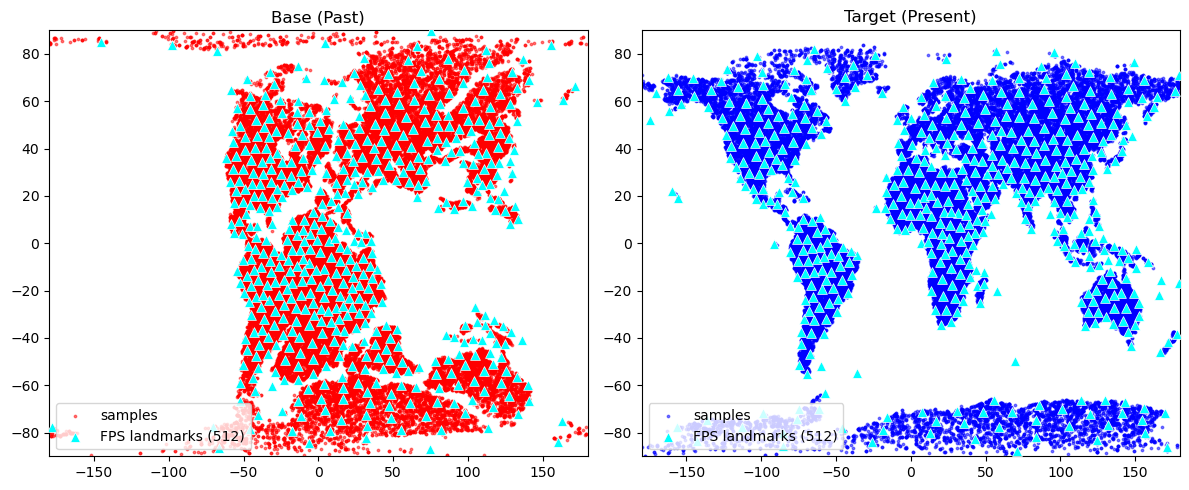

Total landmarks: 1024 (512 from base, 512 from target)


In [3]:
# Visualize the data with landmarks
SEED = cfg.training.seed
key = jax.random.PRNGKey(SEED)
key, k1, k2 = jax.random.split(key, 3)

base_samples = base.sample(k1, 50000)
target_samples = target.sample(k2, 50000)

def xyz_to_latlon(xyz):
    xyz = np.asarray(xyz)
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    lat = np.rad2deg(np.arcsin(np.clip(z, -1, 1)))
    lon = np.rad2deg(np.arctan2(y, x))
    return lat, lon

lat_base, lon_base = xyz_to_latlon(np.array(base_samples))
lat_target, lon_target = xyz_to_latlon(np.array(target_samples))

# Get FPS landmarks from experiment (already built in build_experiment)
landmarks = experiment["landmarks"]
landmarks_base = experiment["landmarks_base"]
landmarks_target = experiment["landmarks_target"]

lat_lm_base, lon_lm_base = xyz_to_latlon(np.array(landmarks_base))
lat_lm_target, lon_lm_target = xyz_to_latlon(np.array(landmarks_target))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Base plot
axes[0].scatter(lon_base, lat_base, s=3, alpha=0.5, c='red', label='samples')
axes[0].scatter(lon_lm_base, lat_lm_base, s=50, marker='^', c='cyan', 
                edgecolors='white', linewidths=0.5, label=f'FPS landmarks ({len(landmarks_base)})', zorder=5)
axes[0].set_title("Base (Past)")
axes[0].set_xlim(-180, 180); axes[0].set_ylim(-90, 90)
axes[0].legend(loc='lower left')

# Target plot
axes[1].scatter(lon_target, lat_target, s=3, alpha=0.5, c='blue', label='samples')
axes[1].scatter(lon_lm_target, lat_lm_target, s=50, marker='^', c='cyan',
                edgecolors='white', linewidths=0.5, label=f'FPS landmarks ({len(landmarks_target)})', zorder=5)
axes[1].set_title("Target (Present)")
axes[1].set_xlim(-180, 180); axes[1].set_ylim(-90, 90)
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

print(f"Total landmarks: {len(landmarks)} ({len(landmarks_base)} from base, {len(landmarks_target)} from target)")

In [4]:
# Train
if save_run:
    state, history = train(experiment)

2026-01-21 20:50:19.919326: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce.92 = f64[1024,1024]{1,0} reduce(f64[1024,1024,3]{2,1,0} %broadcast.395, f64[] %constant.237), dimensions={2}, to_apply=%region_20.644, metadata={op_name="jit(step)/jit(main)/jvp(jit(solve_one))/vmap(while)/body/jvp(MLP)/phi/vmap(vmap(jit(norm)))/reduce_sum" source_file="/home/sjbhatt/riemannian-neural-ot/src/manifolds.py" source_line=189}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


2026-01-21 20:50:21.951036: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.03190107s
Constant folding an instruction is taking > 1s:

  %reduce.92 = f64[1024,1024]{1,0} reduce(f64[1024,1024,3]{2,1,0} %broadcast.395, f64[] %constant.237), dimensions={2}, to_apply=%region_20.644, metadata={op_name="jit(step)/jit(main)/jvp(jit(solve_one))/vmap(while)/body/jvp(MLP)/phi/vmap(vmap(jit(norm)))/reduce_sum" source_file="/home/sjbhatt/riemannian-neural-ot/src/manifolds.py" source_line=189}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


2026-01-21 20:50:23.967180: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %add.99 = f64[1024,1024,1]{2,1,0} add(f64[1024,1024,1]{2,1,0} %constant.279, f64[1024,1024,1]{2,1,0} %broadcast.349), metadata={op_name="jit(step)/jit(main)/jvp(jit(solve_one))/vmap(while)/body/jvp(MLP)/phi/add" source_file="/home/sjbhatt/riemannian-neural-ot/src/manifolds.py" source_line=202}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


2026-01-21 20:50:25.412641: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 3.44558042s
Constant folding an instruction is taking > 2s:

  %add.99 = f64[1024,1024,1]{2,1,0} add(f64[1024,1024,1]{2,1,0} %constant.279, f64[1024,1024,1]{2,1,0} %broadcast.349), metadata={op_name="jit(step)/jit(main)/jvp(jit(solve_one))/vmap(while)/body/jvp(MLP)/phi/add" source_file="/home/sjbhatt/riemannian-neural-ot/src/manifolds.py" source_line=202}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


[     1] loss=0.0603 | res=4.49e-05 | grad=2.83e+00 | 15.2s


...

[   996] loss=-0.1349 | res=1.87e-05 | grad=3.64e-01 | 1.7s


[   997] loss=-0.1507 | res=1.32e-08 | grad=7.98e-01 | 1.7s


[   998] loss=-0.1137 | res=1.42e-08 | grad=1.45e+00 | 1.7s


[   999] loss=-0.1519 | res=1.30e-08 | grad=4.90e-01 | 1.7s


[  1000] loss=-0.1254 | res=1.36e-07 | grad=1.05e+00 | 1.7s


In [5]:
# =============================================================================
# Load Pre-trained Experiment 
# =============================================================================
import pickle
def load_experiment(save_path):
    """Load saved model and rebuild experiment with saved landmarks."""
    with open(save_path, "rb") as f:
        save_data = pickle.load(f)

    cfg = save_data["cfg"]

    # Set device
    if cfg.jax_platform is not None:
        jax.config.update("jax_platform_name", cfg.jax_platform)

    # Get manifold and densities
    manifold = get_manifold(cfg.manifold_name)
    base = EmpiricalSphereDensity(manifold=manifold, csv_path="data/land_points_past.csv")
    target = EmpiricalSphereDensity(manifold=manifold, csv_path="data/land_points_present.csv")

    # Restore saved landmarks (not generate new ones!)
    landmarks = jnp.array(save_data["landmarks"])
    landmarks_base = jnp.array(save_data["landmarks_base"])
    landmarks_target = jnp.array(save_data["landmarks_target"])
    print(f"✓ Restored {len(landmarks)} saved landmarks")

    # Rebuild embedding with saved landmarks
    emb = GromovDistanceEmbedding(manifold=manifold, landmarks=landmarks)

    # Rebuild network with correct embedding
    psi = build_network(
        phi=emb,
        network_type=cfg.model.network_type,
        hidden_dims=cfg.model.hidden_dims,
        use_layernorm=cfg.model.use_layernorm,
        last_scale=cfg.model.last_scale,
        activation=cfg.model.activation,
        leaky_slope=cfg.model.leaky_slope,
        softplus_beta=cfg.model.softplus_beta,
        max_dist=cfg.model.max_dist,
    )

    # Rebuild solver with correct network
    solver = ArgminSolver(
        manifold=manifold,
        psi_module=psi,
        inner_steps=cfg.solver.inner_steps,
        inner_lr=cfg.solver.inner_lr,
        grad_clip=cfg.solver.grad_clip,
        lr_decay=cfg.solver.lr_decay,
        tolerance=cfg.solver.tolerance,
        min_steps=cfg.solver.min_steps,
        momentum=cfg.solver.momentum,
        logsumexp_init=cfg.solver.logsumexp_init,
        logsumexp_gamma=cfg.solver.logsumexp_gamma,
    )

    loss_obj = SemiDualLoss(manifold=manifold, psi_module=psi, solver=solver)

    trainer = SemiDualTrainer(
        manifold=manifold,
        psi_module=psi,
        loss_fn=loss_obj,
        solver=solver,
        learning_rate=cfg.training.learning_rate,
        lr_decay=cfg.training.lr_decay,
        lr_decay_alpha=cfg.training.lr_decay_alpha,
        n_steps=cfg.training.n_steps,
    )

    # Initialize state and restore trained params
    key = jax.random.PRNGKey(cfg.training.seed)
    key, kx_init, kparams = jax.random.split(key, 3)
    x_init = base.sample(kx_init, 16)
    psi_vars = psi.init(kparams, x_init)
    state = trainer.init_state(psi_vars["params"])
    state = state.replace(params=save_data["params"])

    print(f"✓ Restored trained parameters")

    # Restore EMA params if available
    ema_params = save_data.get("ema_params", None)
    if ema_params is not None:
        print(f"✓ Restored EMA parameters")
    else:
        print(f"⚠ No EMA parameters found in save file (using regular params)")
        ema_params = save_data["params"]  # Fallback to regular params

    return {
        "cfg": cfg,
        "manifold": manifold,
        "base": base,
        "target": target,
        "psi": psi,
        "solver": solver,
        "loss": loss_obj,
        "trainer": trainer,
        "state": state,
        "key": key,
        "landmarks": landmarks,
        "landmarks_base": landmarks_base,
        "landmarks_target": landmarks_target,
        "history": save_data["history"],
        "ema_params": ema_params,
    }


if not save_run:
    experiment = load_experiment("saved_runs/continental_drift_20260114_233624.pkl")
    
    # Extract for convenience
    state = experiment["state"]
    history = experiment["history"]
    base = experiment["base"]
    target = experiment["target"]
    
    print(f"✓ Loaded experiment with {len(experiment['landmarks'])} landmarks")

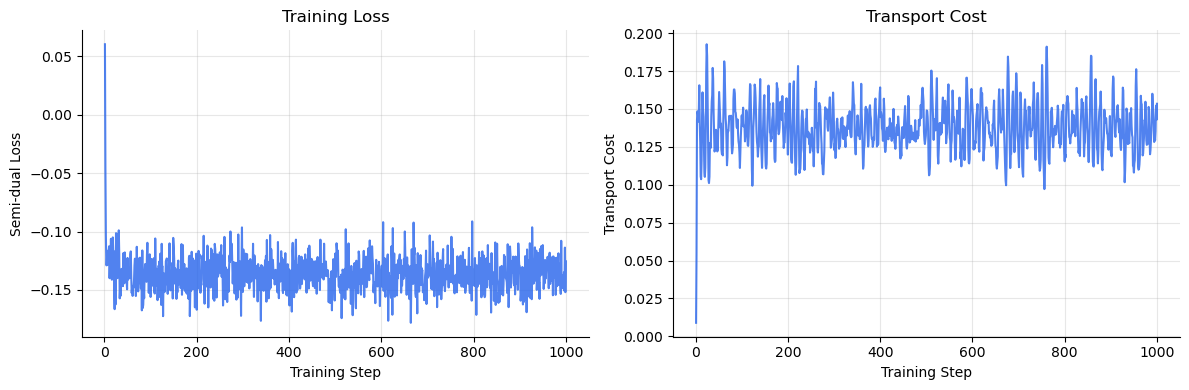

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

steps = np.arange(1, len(history["train_loss"]) + 1) * cfg.training.log_every

# Loss plot
#axes[0].plot(steps, history["eval_loss"], color="#2563eb", linewidth=1.5, alpha=0.8)
#axes[0].plot(steps, history["eval_loss_ema"], color="#10b981", linewidth=1.5, alpha=0.8, label="EMA")
axes[0].plot(steps, history["train_loss"], color="#2563eb", linewidth=1.5, alpha=0.8)

axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Semi-dual Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True, alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)


# Transport cost plot
#axes[1].plot(steps, history["eval_transport_cost"], color="#dc2626", linewidth=1.5, alpha=0.8)
#axes[1].plot(steps, history["eval_transport_cost_ema"], color="#10b981", linewidth=1.5, alpha=0.8, label="EMA")
axes[1].plot(steps, history["train_transport_cost"], color="#2563eb", linewidth=1.5, alpha=0.8)
axes[1].set_xlabel("Training Step")
axes[1].set_ylabel("Transport Cost")
axes[1].set_title("Transport Cost")
axes[1].grid(True, alpha=0.3)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# Evaluation: Use actual CSV points for validation (EmpiricalSpherePointCloud)
# =============================================================================
def do_transport(experiment, xs, y_samples):
    """Transport given points xs using the learned map."""
    solver = experiment["solver"]
    params = experiment["state"].params
    ys, _ = solver.batch_solve(params, xs, y_samples)  # Pass y_samples for logsumexp init
    return ys

# EMA transport (add this)
def do_transport_ema(experiment, xs, y_samples):
    solver = experiment["solver"]
    ema_params = experiment["ema_params"]  # EMA params
    ys, _ = solver.batch_solve(ema_params, xs, y_samples)
    return ys

def xyz_to_latlon_deg(xyz):
    xyz = np.asarray(xyz)
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    lat = np.arcsin(z)
    lon = np.arctan2(y, x)
    return np.stack([np.rad2deg(lat), np.rad2deg(lon)], axis=1)

# Use the actual CSV points for validation (no sampling!)
print("Loading CSV points with plate IDs for validation...")
import pandas as pd
df_past = pd.read_csv("data/land_points_past.csv")
df_present = pd.read_csv("data/land_points_present.csv")

# Take first N points for evaluation
eval_size = min(1024, len(df_past))
lat_past_eval = df_past['lat'].values[:eval_size]
lon_past_eval = df_past['lon'].values[:eval_size]

# Convert to xyz
from src.manifolds import get
manifold = get("S2")

def latlon_to_xyz(lat_deg, lon_deg):
    lat, lon = np.deg2rad(lat_deg), np.deg2rad(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    X = np.stack([x, y, z], axis=-1)
    return X / np.linalg.norm(X, axis=1, keepdims=True)

xs = jnp.array(latlon_to_xyz(lat_past_eval, lon_past_eval))

# Sample target points for logsumexp initialization
key = jax.random.PRNGKey(42)
target_xyz = experiment["target"].sample(key, eval_size)

print(f"✓ Using {len(xs)} actual CSV points from 150 Ma")

# Transport base points
ys = do_transport(experiment, xs, target_xyz)

# Convert to lat/lon for visualization
data_latlon_base = xyz_to_latlon_deg(xs)
data_latlon_target = xyz_to_latlon_deg(target_xyz)
ys_latlon = xyz_to_latlon_deg(ys)

print(f"✓ Transported {len(xs)} points")
print(f"✓ Base samples: {len(xs)}")
print(f"✓ Target samples: {len(target_xyz)}")

Loading CSV points with plate IDs for validation...
✓ Using 1024 actual CSV points from 150 Ma


2026-01-21 21:18:37.614009: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 4s:

  %add.95 = f64[1024,1024,1]{2,1,0} add(f64[1024,1024,1]{2,1,0} %constant.185, f64[1024,1024,1]{2,1,0} %broadcast.245), metadata={op_name="jit(solve_one)/jit(main)/vmap(while)/body/jvp(MLP)/phi/add" source_file="/home/sjbhatt/riemannian-neural-ot/src/manifolds.py" source_line=202}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


2026-01-21 21:18:38.731106: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.117225977s
Constant folding an instruction is taking > 4s:

  %add.95 = f64[1024,1024,1]{2,1,0} add(f64[1024,1024,1]{2,1,0} %constant.185, f64[1024,1024,1]{2,1,0} %broadcast.245), metadata={op_name="jit(solve_one)/jit(main)/vmap(while)/body/jvp(MLP)/phi/add" source_file="/home/sjbhatt/riemannian-neural-ot/src/manifolds.py" source_line=202}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.


✓ Transported 1024 points
✓ Base samples: 1024
✓ Target samples: 1024


CONVERGENCE ANALYSIS
Solver: GD, steps=2500, lr=0.05, tol=1e-06

Residual Statistics (N=1024):
  Min:    2.25e-16
  Median: 1.27e-15
  Mean:   2.24e-07
  P90:    7.84e-12
  P99:    5.41e-07
  Max:    1.39e-04

Convergence: 99.8% (1022/1024)

Failing samples (2):


  [  18] res=1.39e-04, init_dist=0.352, final_dist=0.357
  [ 291] res=7.91e-05, init_dist=0.170, final_dist=0.463

Init distance comparison:


  Passing samples: mean=0.452


  Failing samples: mean=0.261


CONVERGENCE ANALYSIS
Solver: GD, steps=2500, lr=0.05, tol=1e-06

Residual Statistics (N=1024):
  Min:    2.47e-16
  Median: 1.26e-15
  Mean:   1.30e-08
  P90:    4.79e-12
  P99:    7.25e-07
  Max:    9.99e-07

Convergence: 100.0% (1024/1024)


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Residual Distribution | GD, 2500 steps, lr=0.05'}, xlabel='Gradient Residual (||∇f||)', ylabel='Count'>)

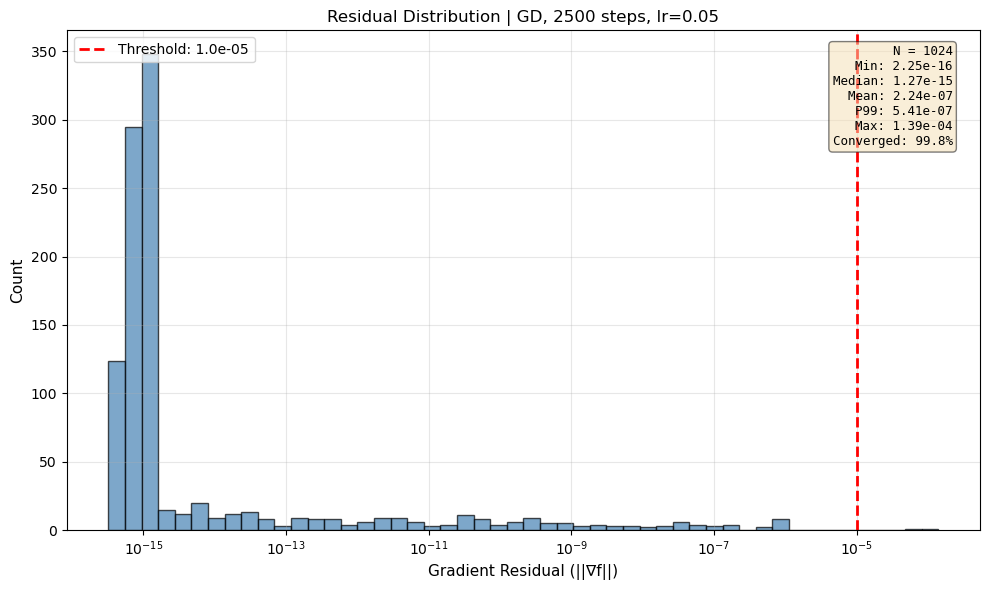

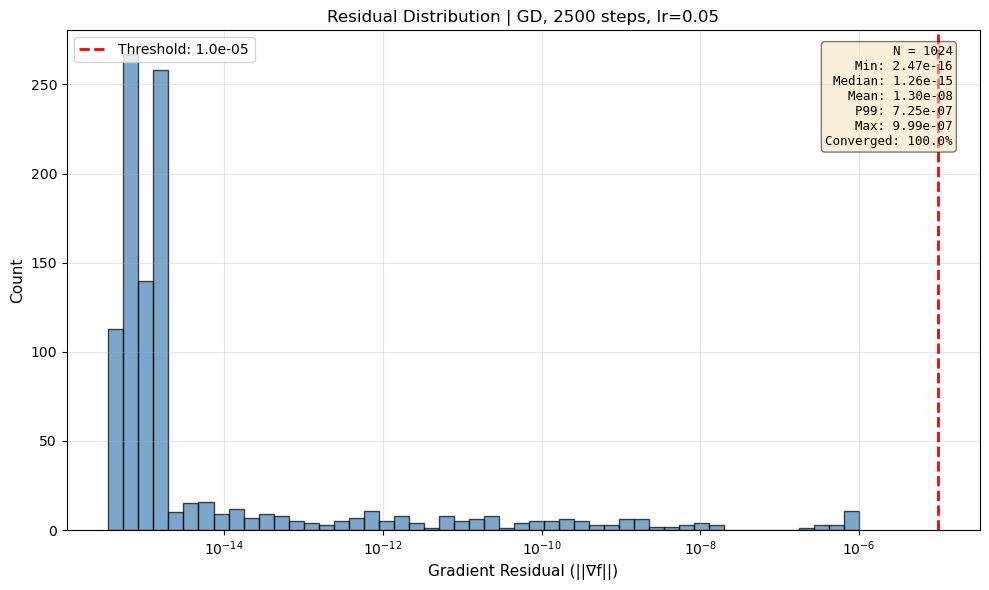

In [8]:
# Same inputs
xs = jnp.array(latlon_to_xyz(lat_past_eval, lon_past_eval))  # source points
y_samples = target_xyz  # target samples for init

# Compare regular vs EMA
analysis_regular = experiment["solver"].analyze_convergence(experiment["state"].params, xs, y_samples)
experiment["solver"].print_convergence_report(analysis_regular, plot=True)

analysis_ema = experiment["solver"].analyze_convergence(experiment["ema_params"], xs, y_samples)
experiment["solver"].print_convergence_report(analysis_ema, plot=True)

In [9]:

# Compute Monge gap for regular params (to compare)
gap_regular = experiment["solver"].compute_monge_gap(
    experiment["state"].params,
    xs,
    target_xyz
)

# Print results
print("=" * 50)
print("MONGE GAP ANALYSIS")
print("=" * 50)
print(f"\nRegular params:")
print(f"  Monge gap:       {gap_regular['monge_gap']:.6f}")
print(f"  Transport cost:  {gap_regular['transport_cost']:.6f}")
print(f"  Dual value (≈W₂): {gap_regular['dual_value']:.6f}")
print(f"  Mean distance:   {gap_regular['mean_dist']:.4f}")


MONGE GAP ANALYSIS

Regular params:
  Monge gap:       0.001549
  Transport cost:  0.139368
  Dual value (≈W₂): 0.137819
  Mean distance:   0.4798


In [10]:
# =============================================================================
# Evaluation: Transport Cost (using already computed xs and ys)
# =============================================================================
def compute_single_cost(x, y):
    """Compute ½ * geodesic_distance² between two points on the sphere."""
    inner = jnp.dot(x, y)
    inner = jnp.clip(inner, -1.0 + 1e-12, 1.0 - 1e-12)
    dist = jnp.arccos(inner)
    return 0.5 * dist**2

transport_costs = jax.vmap(compute_single_cost)(xs, ys)
mean_transport_cost = float(jnp.mean(transport_costs))
mean_geodesic_dist = np.sqrt(2 * mean_transport_cost)

print("=" * 60)
print("Transport Cost Evaluation")
print("=" * 60)
print(f"Samples evaluated: {len(xs)}")
print(f"Transport Cost E[½ * d(x, T(x))²]: {mean_transport_cost:.6f}")
print(f"Mean geodesic distance: {mean_geodesic_dist:.6f} radians")
print(f"Mean geodesic distance: {np.rad2deg(mean_geodesic_dist):.2f} degrees")


Transport Cost Evaluation
Samples evaluated: 1024
Transport Cost E[½ * d(x, T(x))²]: 0.139368
Mean geodesic distance: 0.527954 radians
Mean geodesic distance: 30.25 degrees


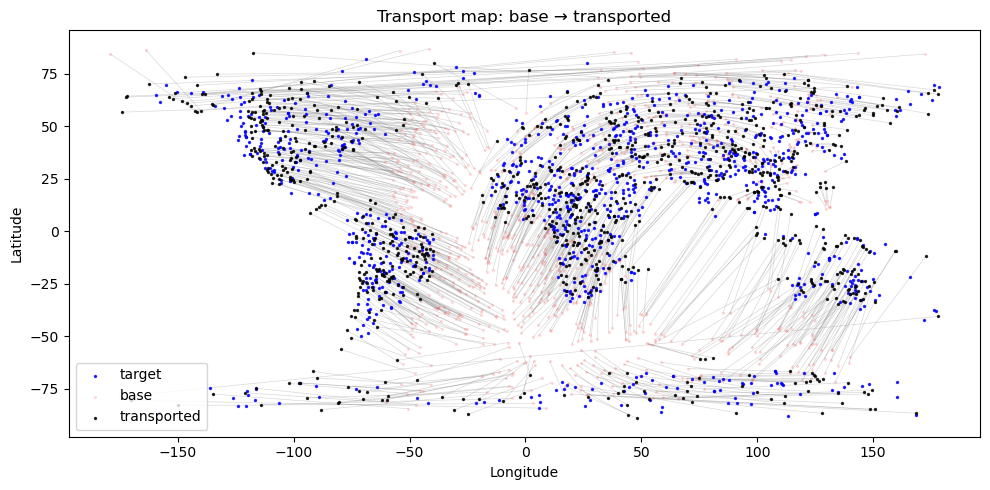

In [11]:
# Get landmarks for plotting
landmarks = experiment["landmarks"]
lat_lm, lon_lm = xyz_to_latlon(np.array(landmarks))

plt.figure(figsize=(10, 5))

# Draw transport lines (subsample for visibility)
n_lines = 5000  # number of transport lines to show
indices = np.random.choice(len(data_latlon_base), min(n_lines, len(data_latlon_base)), replace=False)

for i in indices:
    plt.plot(
        [data_latlon_base[i, 1], ys_latlon[i, 1]],
        [data_latlon_base[i, 0], ys_latlon[i, 0]],
        color='gray', alpha=0.3, linewidth=0.5, zorder=1
    )

plt.scatter(
    data_latlon_target[:, 1], data_latlon_target[:, 0],
    s=2, alpha=0.8, color='blue', label="target",
)

plt.scatter(
    data_latlon_base[:, 1], data_latlon_base[:, 0],
    s=2, alpha=0.1, color='red', label="base",
)

plt.scatter(
    ys_latlon[:, 1], ys_latlon[:, 0],
    s=2, alpha=0.8, color='black', label="transported",
)

# Add landmarks as cyan triangles
#plt.scatter(
#    lon_lm, lat_lm,
#    s=50, marker='^', c='cyan', edgecolors='darkblue',
#    linewidths=0.5, label=f"landmarks ({len(landmarks)})", zorder=10
#)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='lower left') 
plt.title("Transport map: base → transported")
plt.tight_layout()
plt.show()



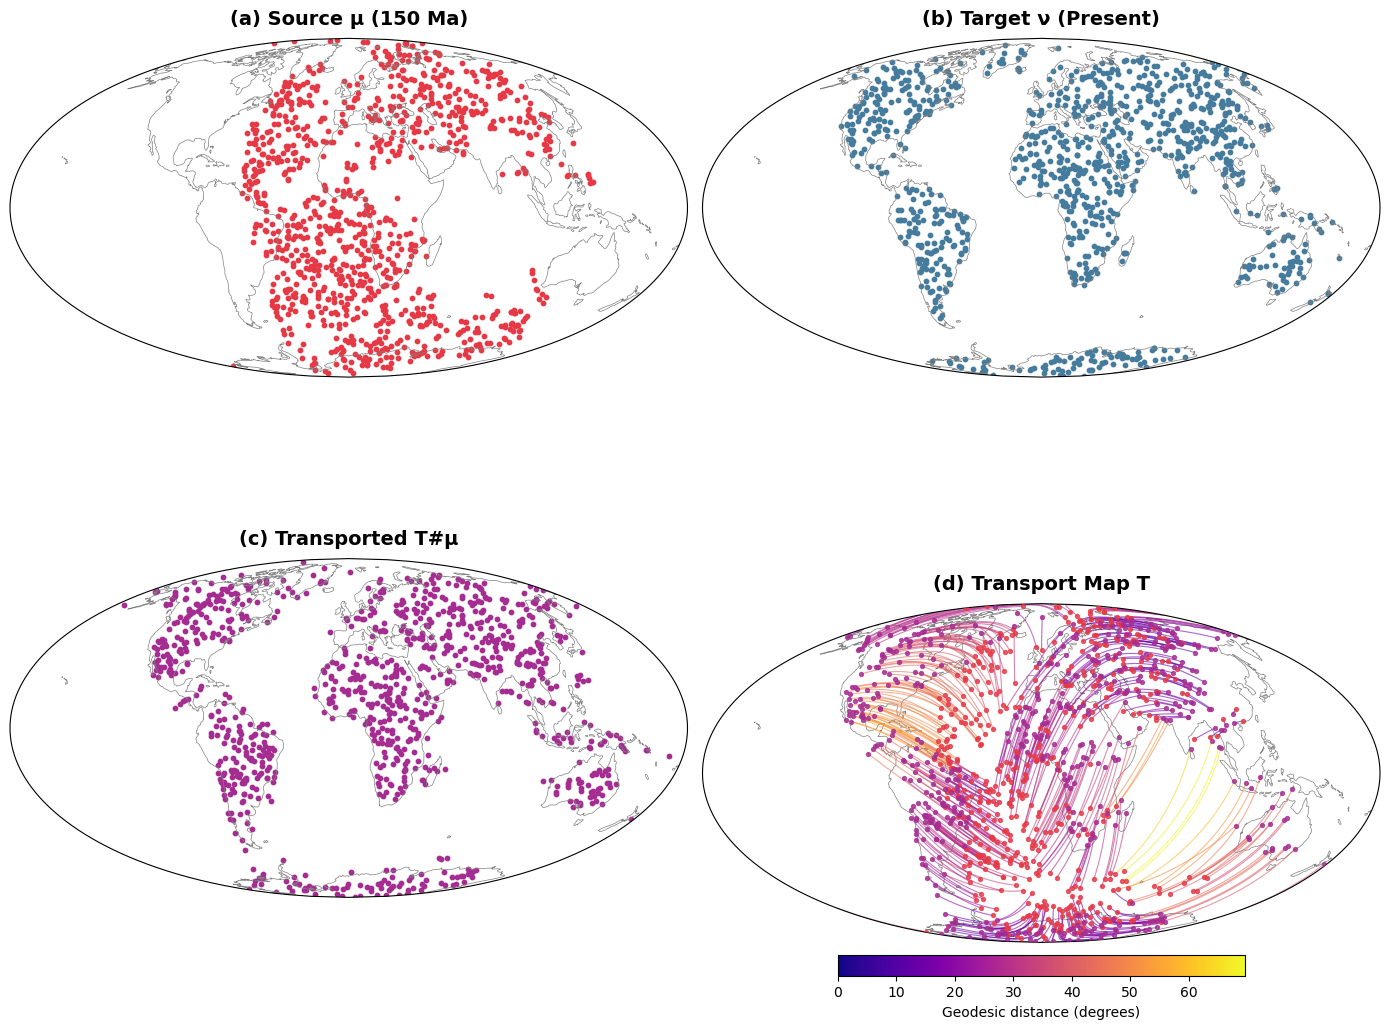

Saved: continental_drift_2x2.png


In [12]:
# =============================================================================
# 2x2 Continental Drift Figure with Geodesic Transport Lines
# =============================================================================
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

def geodesic_path_latlon(lat1, lon1, lat2, lon2, n_points=50):
    """
    Compute geodesic path between two points on sphere.
    Returns arrays of (lat, lon) along the great circle.
    """
    # Convert to radians
    lat1_r, lon1_r = np.deg2rad(lat1), np.deg2rad(lon1)
    lat2_r, lon2_r = np.deg2rad(lat2), np.deg2rad(lon2)
    
    # Convert to xyz
    x1 = np.cos(lat1_r) * np.cos(lon1_r)
    y1 = np.cos(lat1_r) * np.sin(lon1_r)
    z1 = np.sin(lat1_r)
    
    x2 = np.cos(lat2_r) * np.cos(lon2_r)
    y2 = np.cos(lat2_r) * np.sin(lon2_r)
    z2 = np.sin(lat2_r)
    
    # Interpolate on sphere using slerp
    p1 = np.array([x1, y1, z1])
    p2 = np.array([x2, y2, z2])
    
    dot = np.clip(np.dot(p1, p2), -1, 1)
    omega = np.arccos(dot)
    
    if omega < 1e-6:  # Points are essentially the same
        return np.array([lat1]), np.array([lon1])
    
    t = np.linspace(0, 1, n_points)
    
    # Slerp formula
    sin_omega = np.sin(omega)
    paths = np.outer(np.sin((1-t)*omega)/sin_omega, p1) + np.outer(np.sin(t*omega)/sin_omega, p2)
    
    # Normalize (should already be unit length, but numerical safety)
    paths = paths / np.linalg.norm(paths, axis=1, keepdims=True)
    
    # Convert back to lat/lon
    lats = np.rad2deg(np.arcsin(np.clip(paths[:, 2], -1, 1)))
    lons = np.rad2deg(np.arctan2(paths[:, 1], paths[:, 0]))
    
    return lats, lons


def sample_latitude_band_points(base_latlon, n_bands=10, n_per_band=30):
    """
    Sample points along latitude bands from the base distribution.
    Returns indices of selected points.
    """
    lats = base_latlon[:, 0]
    
    # Define latitude bands
    lat_edges = np.linspace(lats.min(), lats.max(), n_bands + 1)
    
    selected_indices = []
    for i in range(n_bands):
        mask = (lats >= lat_edges[i]) & (lats < lat_edges[i+1])
        band_indices = np.where(mask)[0]
        if len(band_indices) > 0:
            # Sample evenly spaced points by longitude within this band
            band_lons = base_latlon[band_indices, 1]
            sorted_idx = np.argsort(band_lons)
            step = max(1, len(sorted_idx) // n_per_band)
            selected = band_indices[sorted_idx[::step][:n_per_band]]
            selected_indices.extend(selected)
    
    return np.array(selected_indices)


# Create 2x2 figure
fig = plt.figure(figsize=(14, 12))
proj = ccrs.Mollweide()

# Subplot positions
positions = [(2, 2, 1), (2, 2, 2), (2, 2, 3), (2, 2, 4)]
titles = ["(a) Source μ (150 Ma)", "(b) Target ν (Present)", 
          "(c) Transported T#μ", "(d) Transport Map T"]
colors = ["#e63946", "#457b9d", "#a52d91", None]
data = [data_latlon_base, data_latlon_target, ys_latlon, None]

for idx, (pos, title, color, latlon) in enumerate(zip(positions, titles, colors, data)):
    ax = fig.add_subplot(*pos, projection=proj)
    ax.set_global()
    ax.coastlines(lw=0.5, alpha=1, color='gray')
    
    if idx < 3:  # Scatter plots for first 3 panels
        lon, lat = latlon[:, 1], latlon[:, 0]
        ax.scatter(lon, lat, s=10, alpha=1, c=color,
                   transform=ccrs.PlateCarree(), rasterized=True)
    
    else:  # Transport lines for 4th panel
        # Sample points along latitude bands
        indices = sample_latitude_band_points(data_latlon_base, n_bands=12, n_per_band=50)
        
        # Subsample if too many
       # if len(indices) > 400:
       #     indices = np.random.choice(indices, 400, replace=False)
        
        # Compute geodesic distances for coloring
        distances = []
        for i in indices:
            src_lat, src_lon = data_latlon_base[i, 0], data_latlon_base[i, 1]
            dst_lat, dst_lon = ys_latlon[i, 0], ys_latlon[i, 1]
            
            # Geodesic distance in radians
            src_xyz = np.array([np.cos(np.deg2rad(src_lat)) * np.cos(np.deg2rad(src_lon)),
                                np.cos(np.deg2rad(src_lat)) * np.sin(np.deg2rad(src_lon)),
                                np.sin(np.deg2rad(src_lat))])
            dst_xyz = np.array([np.cos(np.deg2rad(dst_lat)) * np.cos(np.deg2rad(dst_lon)),
                                np.cos(np.deg2rad(dst_lat)) * np.sin(np.deg2rad(dst_lon)),
                                np.sin(np.deg2rad(dst_lat))])
            dist = np.arccos(np.clip(np.dot(src_xyz, dst_xyz), -1, 1))
            distances.append(dist)
        
        distances = np.array(distances)
        max_dist = distances.max() if len(distances) > 0 else 1.0
        
        # Draw geodesic paths with color gradient
        cmap = plt.cm.plasma
        
        for i, idx_pt in enumerate(indices):
            src_lat, src_lon = data_latlon_base[idx_pt, 0], data_latlon_base[idx_pt, 1]
            dst_lat, dst_lon = ys_latlon[idx_pt, 0], ys_latlon[idx_pt, 1]
            
            # Get geodesic path
            path_lats, path_lons = geodesic_path_latlon(src_lat, src_lon, dst_lat, dst_lon, n_points=30)
            
            # Color by distance
            color_val = distances[i] / max_dist
            line_color = cmap(color_val)
            
            # Draw path as colored segments
            ax.plot(path_lons, path_lats, 
                    transform=ccrs.Geodetic(),
                    color=line_color, linewidth=0.8, alpha=0.6)
        
        # Add source points (small red dots)
        src_lons = data_latlon_base[indices, 1]
        src_lats = data_latlon_base[indices, 0]
        ax.scatter(src_lons, src_lats, s=8, c='#e63946', alpha=0.8,
                   transform=ccrs.PlateCarree(), zorder=10, label='Source')
        
        # Add destination points (small purple dots)  
        dst_lons = ys_latlon[indices, 1]
        dst_lats = ys_latlon[indices, 0]
        ax.scatter(dst_lons, dst_lats, s=8, c='#a52d91', alpha=0.8,
                   transform=ccrs.PlateCarree(), zorder=10, label='Transported')
        
        # Add colorbar for distance
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, np.rad2deg(max_dist)))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, shrink=0.6)
        cbar.set_label('Geodesic distance (degrees)', fontsize=10)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('continental_drift_2x2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Saved: continental_drift_2x2.png")


In [13]:
# =============================================================================
# KL Divergence Evaluation
# =============================================================================
from src.metrics import compute_kl_divergence_autodiff

# Use a smaller sample for KL (Jacobian computation is expensive)
kl_eval_size = 1024
key = jax.random.PRNGKey(123)
k1, k2 = jax.random.split(key)

# Sample from base and target
xs_kl = experiment["base"].sample(k1, kl_eval_size)
target_samples_kl = experiment["target"].sample(k2, kl_eval_size)

# Compute KL divergence using autodiff
print("Computing KL divergence (this may take a moment)...")
kl_result = compute_kl_divergence_autodiff(
    psi_params=experiment["state"].params,
    xs=xs_kl,
    base_density=experiment["base"],
    target_density=experiment["target"],
    solver=experiment["solver"],
    manifold=experiment["manifold"],
    y_samples=target_samples_kl,
)

print("=" * 60)
print("KL Divergence Evaluation: KL(T#base || target)")
print("=" * 60)
print(f"Samples: {kl_eval_size}")
print(f"KL divergence:     {kl_result.kl:.6f}")
print(f"  E[log μ(x)]:     {kl_result.log_mu:.6f}")
print(f"  E[log ν(T(x))]:  {kl_result.log_nu:.6f}")
print(f"  E[log|det J|]:   {kl_result.log_det_J:.6f}")
print("-" * 60)
if kl_result.kl < 0:
    print("Warning: KL < 0 indicates a bug in Jacobian computation")

Computing KL divergence (this may take a moment)...


KL Divergence Evaluation: KL(T#base || target)
Samples: 1024
KL divergence:     0.309173
  E[log μ(x)]:     -1.451953
  E[log ν(T(x))]:  -1.698237
  E[log|det J|]:   -0.062889
------------------------------------------------------------


In [14]:
# =============================================================================
# Plate Label Preservation Analysis (using CSV plate IDs with nearest neighbor)
# =============================================================================
import pandas as pd
from scipy.spatial import cKDTree

def latlon_to_xyz(lat_deg, lon_deg):
    """Convert lat/lon in degrees to unit vectors on S²."""
    lat, lon = np.deg2rad(lat_deg), np.deg2rad(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    X = np.stack([x, y, z], axis=-1)
    return X / np.linalg.norm(X, axis=1, keepdims=True)

# Load plate IDs directly from CSV
print("Loading plate IDs from CSV...")
df_past = pd.read_csv("data/land_points_past.csv")
df_present = pd.read_csv("data/land_points_present.csv")

if 'plate_id' not in df_past.columns:
    print("❌ ERROR: plate_id column not found!")
    raise ValueError("Missing plate_id column")

# Get plate IDs for source points (exact match from CSV)
plate_ids_source = df_past['plate_id'].values[:eval_size]

print(f"✓ Loaded {eval_size} source plate IDs")
print(f"  Unique source plates: {len(np.unique(plate_ids_source[plate_ids_source >= 0]))}")

# Assign transported points using nearest neighbor to present-day CSV points
print("\nAssigning transported points using nearest neighbor to present CSV...")

# Build KDTree from present-day CSV points (in xyz coordinates)
present_xyz = latlon_to_xyz(df_present['lat'].values, df_present['lon'].values)
tree = cKDTree(present_xyz)

# Find nearest present-day point for each transported point
distances, indices = tree.query(np.array(ys), k=1)

# Assign plate IDs from nearest neighbors
plate_ids_transported = df_present['plate_id'].values[indices]

print(f"✓ Assigned {len(plate_ids_transported)} transported points")
print(f"  Unique destination plates: {len(np.unique(plate_ids_transported[plate_ids_transported >= 0]))}")
print(f"  Mean distance to nearest present point: {np.rad2deg(np.mean(distances)):.2f}°")

# Create plate name mappings from CSV
# For simplicity, use plate IDs as names (we'd need GPlates for actual names)
unique_past_plates = df_past['plate_id'].unique()
unique_present_plates = df_present['plate_id'].unique()

plate_names_past = {int(pid): f"Plate {int(pid)}" for pid in unique_past_plates if pid >= 0}
plate_names_present = {int(pid): f"Plate {int(pid)}" for pid in unique_present_plates if pid >= 0}

print(f"\n✓ Ready for plate validation!")
print(f"  (Note: Using plate IDs as names since we're not fetching from GPlates)")

Loading plate IDs from CSV...
✓ Loaded 1024 source plate IDs
  Unique source plates: 18

Assigning transported points using nearest neighbor to present CSV...
✓ Assigned 1024 transported points
  Unique destination plates: 25
  Mean distance to nearest present point: 0.54°

✓ Ready for plate validation!
  (Note: Using plate IDs as names since we're not fetching from GPlates)


In [15]:
# =============================================================================
# Plate Label Preservation Metrics
# =============================================================================

def check_plate_label_preservation(plate_ids_source, plate_ids_transported, plate_names_past, plate_names_present):
    """Check if each past plate maps to a consistent present-day plate."""
    
    confusion = {}
    for past_plate in np.unique(plate_ids_source):
        if past_plate < 0:  # Skip unassigned
            continue
            
        mask = plate_ids_source == past_plate
        
        # What plates do these points end up in?
        transported_pids = plate_ids_transported[mask]
        present_plates_unique, counts = np.unique(transported_pids[transported_pids >= 0], return_counts=True)
        
        if len(present_plates_unique) == 0:
            continue
        
        # Primary destination (most points)
        primary_dest = present_plates_unique[np.argmax(counts)]
        purity = np.max(counts) / mask.sum()  # Fraction going to primary destination
        
        confusion[past_plate] = {
            'primary_destination': primary_dest,
            'purity': purity,
            'n_points': mask.sum(),
            'destinations': dict(zip(present_plates_unique.tolist(), counts.tolist()))
        }
    
    return confusion

# Compute confusion matrix
print("\n" + "="*70)
print("PLATE LABEL PRESERVATION ANALYSIS")
print("="*70)

confusion = check_plate_label_preservation(
    plate_ids_source, 
    plate_ids_transported,
    plate_names_past,
    plate_names_present
)

# Print results
print(f"\nTotal plates analyzed: {len(confusion)}")
print(f"\nPlate mapping quality:")
print("-"*70)

for past_pid in sorted(confusion.keys(), key=lambda p: -confusion[p]['n_points'])[:10]:
    info = confusion[past_pid]
    past_name = plate_names_past.get(past_pid, f"Plate {past_pid}")
    dest_name = plate_names_present.get(info['primary_destination'], f"Plate {info['primary_destination']}")
    
    print(f"{past_name[:30]:30s} → {dest_name[:30]:30s}")
    print(f"  Purity: {info['purity']:6.1%} | Points: {info['n_points']:5d}")
    
    # Show all destinations if purity < 80%
    if info['purity'] < 0.80 and len(info['destinations']) > 1:
        print(f"  ⚠️  Low purity! Destinations:")
        for dest_pid, count in sorted(info['destinations'].items(), key=lambda x: -x[1])[:3]:
            dest_name_short = plate_names_present.get(dest_pid, f"Plate {dest_pid}")
            print(f"      {dest_name_short[:40]:40s}: {count:5d} points ({100*count/info['n_points']:5.1f}%)")
    print()

# Compute summary statistics
purities = [info['purity'] for info in confusion.values()]
mean_purity = np.mean(purities)
weighted_purity = np.sum([info['purity'] * info['n_points'] for info in confusion.values()]) / sum([info['n_points'] for info in confusion.values()])

print("="*70)
print(f"Summary:")
print(f"  Mean purity: {mean_purity:.2%}")
print(f"  Weighted purity: {weighted_purity:.2%}")
print(f"  Plates with purity > 90%: {sum(1 for p in purities if p > 0.90)} / {len(purities)}")
print(f"  Plates with purity > 80%: {sum(1 for p in purities if p > 0.80)} / {len(purities)}")
print("="*70)


PLATE LABEL PRESERVATION ANALYSIS

Total plates analyzed: 18

Plate mapping quality:
----------------------------------------------------------------------
Plate 701                      → Plate 701                     
  Purity:  48.7% | Points:   347
  ⚠️  Low purity! Destinations:
      Plate 701                               :   169 points ( 48.7%)
      Plate 201                               :   131 points ( 37.8%)
      Plate 503                               :    16 points (  4.6%)

Plate 301                      → Plate 301                     
  Purity:  80.3% | Points:   188

Plate 101                      → Plate 101                     
  Purity:  85.8% | Points:   155

Plate 801                      → Plate 801                     
  Purity:  42.5% | Points:   113
  ⚠️  Low purity! Destinations:
      Plate 801                               :    48 points ( 42.5%)
      Plate 709                               :    20 points ( 17.7%)
      Plate 604                       

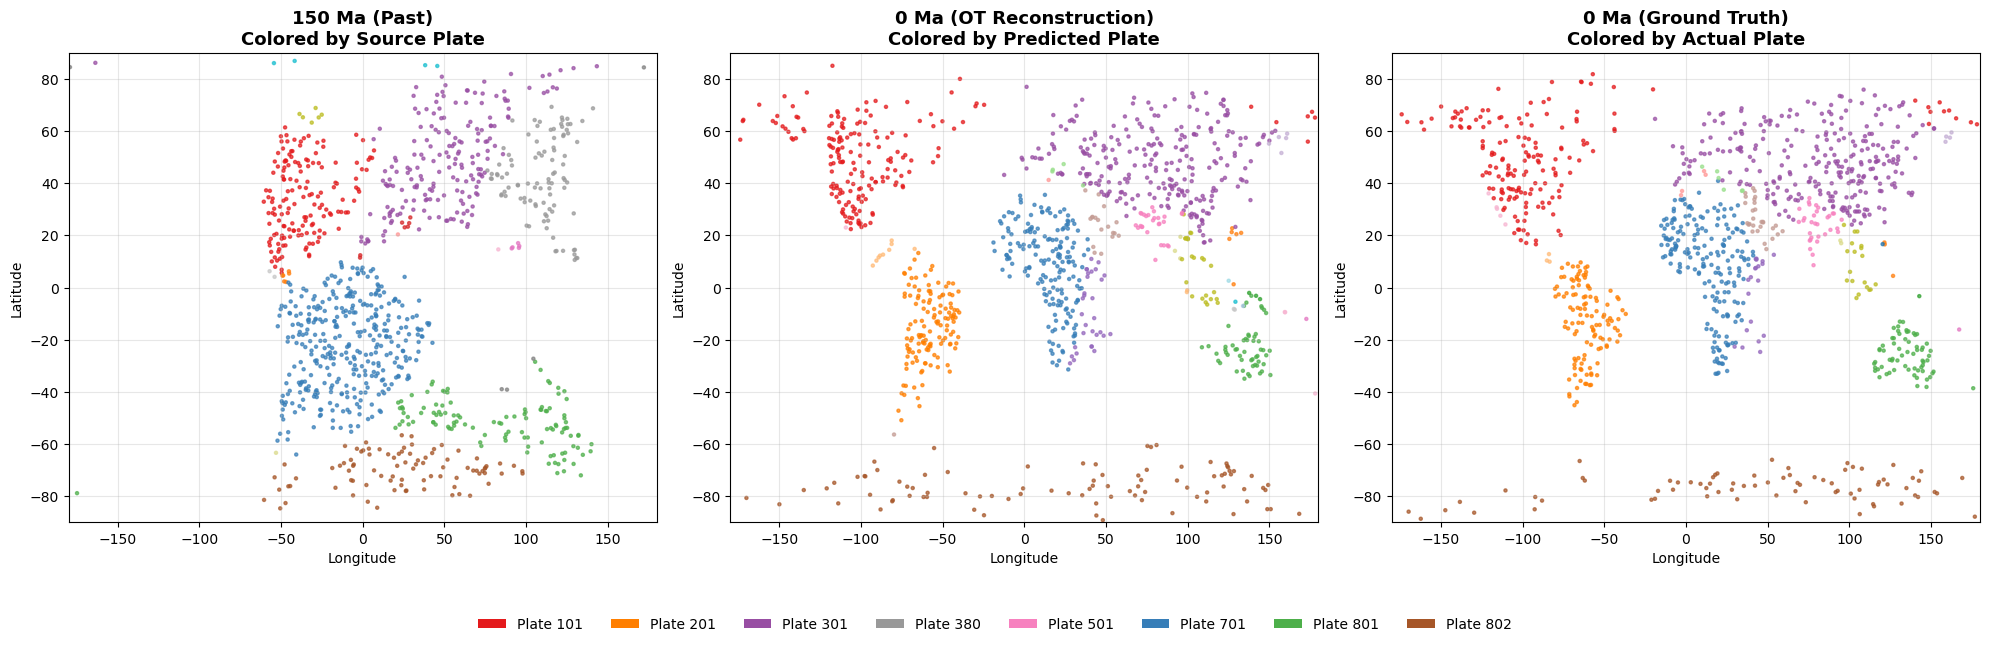


📊 Interpretation:
  - Left: Original plate configuration at 150 Ma
  - Middle: Where OT transported those points (predicted present-day plates)
  - Right: Actual present-day plate configuration (ground truth)
  - Compare middle vs right: How well does OT match reality?
  - High purity = colors in middle match right panel → good reconstruction


In [16]:
# =============================================================================
# Visualization: Reconstruction Map Colored by Plates (with ground truth)
# =============================================================================
import matplotlib.colors as mcolors

# Manual color assignment for major plates (same as data notebook)
major_plate_colors = {
    101: '#e41a1c',  # North America - red
    201: '#ff7f00',  # South America - orange  
    301: '#984ea3',  # Eurasia - purple
    701: '#377eb8',  # Africa - blue
    801: '#4daf4a',  # Australia - green
    802: '#a65628',  # Antarctica - brown
    501: '#f781bf',  # India - pink
    380: '#999999',  # Mongol-Okhotsk - gray
}

def create_plate_colormap(all_plate_ids, major_colors):
    """Create custom colormap for plate visualization."""
    colors = []
    for pid in all_plate_ids:
        if pid < 0:
            colors.append('#cccccc')  # Gray for unassigned
        elif pid in major_colors:
            colors.append(major_colors[pid])
        else:
            idx = len(colors) % 20
            colors.append(plt.cm.tab20(idx))
    return mcolors.ListedColormap(colors)

# Load actual present-day data for ground truth comparison
df_present_gt = pd.read_csv("data/land_points_present.csv")
plate_ids_present_gt = df_present_gt['plate_id'].values[:eval_size]
lat_present_gt = df_present_gt['lat'].values[:eval_size]
lon_present_gt = df_present_gt['lon'].values[:eval_size]

# Get all unique plate IDs (including ground truth)
all_past_pids = np.unique(plate_ids_source)
all_present_pids = np.unique(plate_ids_transported)
all_gt_pids = np.unique(plate_ids_present_gt)
all_plate_ids = np.unique(np.concatenate([all_past_pids, all_present_pids, all_gt_pids]))

# Create colormaps
cmap = create_plate_colormap(all_plate_ids, major_plate_colors)
id_to_idx = {pid: i for i, pid in enumerate(all_plate_ids)}

# Map plate IDs to color indices
colors_source = np.array([id_to_idx.get(pid, 0) for pid in plate_ids_source])
colors_transported = np.array([id_to_idx.get(pid, 0) for pid in plate_ids_transported])
colors_gt = np.array([id_to_idx.get(pid, 0) for pid in plate_ids_present_gt])

# Create the plot with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Past (source) plot
axes[0].scatter(data_latlon_base[:, 1], data_latlon_base[:, 0], 
                c=colors_source, cmap=cmap, vmin=0, vmax=len(all_plate_ids)-1,
                s=5, alpha=0.7)
axes[0].set_title(f"150 Ma (Past)\nColored by Source Plate", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)
axes[0].grid(True, alpha=0.3)

# Transported points colored by destination plate
axes[1].scatter(ys_latlon[:, 1], ys_latlon[:, 0], 
                c=colors_transported, cmap=cmap, vmin=0, vmax=len(all_plate_ids)-1,
                s=5, alpha=0.7)
axes[1].set_title(f"0 Ma (OT Reconstruction)\nColored by Predicted Plate", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_xlim(-180, 180)
axes[1].set_ylim(-90, 90)
axes[1].grid(True, alpha=0.3)

# Ground truth present-day
axes[2].scatter(lon_present_gt, lat_present_gt, 
                c=colors_gt, cmap=cmap, vmin=0, vmax=len(all_plate_ids)-1,
                s=5, alpha=0.7)
axes[2].set_title(f"0 Ma (Ground Truth)\nColored by Actual Plate", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].set_xlim(-180, 180)
axes[2].set_ylim(-90, 90)
axes[2].grid(True, alpha=0.3)

# Add legend for major plates
from matplotlib.patches import Patch
legend_elements = []
for pid, color in sorted(major_plate_colors.items()):
    name = plate_names_present.get(pid, plate_names_past.get(pid, f"Plate {pid}"))
    if pid in all_plate_ids:
        legend_elements.append(Patch(facecolor=color, label=name[:20]))

fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, -0.05), 
          ncol=len(legend_elements), frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

print("\n📊 Interpretation:")
print("  - Left: Original plate configuration at 150 Ma")
print("  - Middle: Where OT transported those points (predicted present-day plates)")
print("  - Right: Actual present-day plate configuration (ground truth)")
print("  - Compare middle vs right: How well does OT match reality?")
print("  - High purity = colors in middle match right panel → good reconstruction")

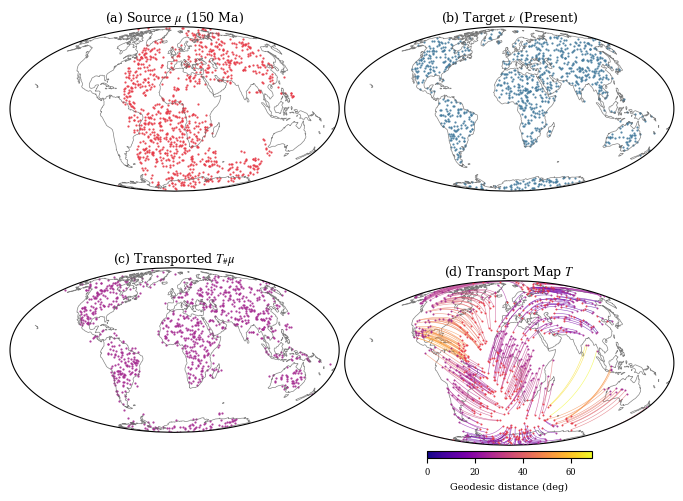

Saved: continental_drift_icml.pdf


In [17]:
# =============================================================================
# 2x2 Continental Drift Figure - ICML Format
# =============================================================================
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.collections import LineCollection

# ICML formatting
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 9,
    'text.usetex': False,  # Set True if LaTeX available
    'mathtext.fontset': 'stix',
})

def geodesic_path_latlon(lat1, lon1, lat2, lon2, n_points=50):
    """Compute geodesic path between two points on sphere."""
    lat1_r, lon1_r = np.deg2rad(lat1), np.deg2rad(lon1)
    lat2_r, lon2_r = np.deg2rad(lat2), np.deg2rad(lon2)
    
    x1 = np.cos(lat1_r) * np.cos(lon1_r)
    y1 = np.cos(lat1_r) * np.sin(lon1_r)
    z1 = np.sin(lat1_r)
    
    x2 = np.cos(lat2_r) * np.cos(lon2_r)
    y2 = np.cos(lat2_r) * np.sin(lon2_r)
    z2 = np.sin(lat2_r)
    
    p1 = np.array([x1, y1, z1])
    p2 = np.array([x2, y2, z2])
    
    dot = np.clip(np.dot(p1, p2), -1, 1)
    omega = np.arccos(dot)
    
    if omega < 1e-6:
        return np.array([lat1]), np.array([lon1])
    
    t = np.linspace(0, 1, n_points)
    sin_omega = np.sin(omega)
    paths = np.outer(np.sin((1-t)*omega)/sin_omega, p1) + np.outer(np.sin(t*omega)/sin_omega, p2)
    paths = paths / np.linalg.norm(paths, axis=1, keepdims=True)
    
    lats = np.rad2deg(np.arcsin(np.clip(paths[:, 2], -1, 1)))
    lons = np.rad2deg(np.arctan2(paths[:, 1], paths[:, 0]))
    
    return lats, lons


def sample_latitude_band_points(base_latlon, n_bands=10, n_per_band=30):
    """Sample points along latitude bands from the base distribution."""
    lats = base_latlon[:, 0]
    lat_edges = np.linspace(lats.min(), lats.max(), n_bands + 1)
    
    selected_indices = []
    for i in range(n_bands):
        mask = (lats >= lat_edges[i]) & (lats < lat_edges[i+1])
        band_indices = np.where(mask)[0]
        if len(band_indices) > 0:
            band_lons = base_latlon[band_indices, 1]
            sorted_idx = np.argsort(band_lons)
            step = max(1, len(sorted_idx) // n_per_band)
            selected = band_indices[sorted_idx[::step][:n_per_band]]
            selected_indices.extend(selected)
    
    return np.array(selected_indices)


# ICML double-column width: 6.75 inches
# Height adjusted for 2x2 with good aspect ratio for Mollweide
fig = plt.figure(figsize=(6.75, 5.5))
proj = ccrs.Mollweide()

# Subplot positions with tighter spacing
positions = [(2, 2, 1), (2, 2, 2), (2, 2, 3), (2, 2, 4)]
titles = [r"(a) Source $\mu$ (150 Ma)", r"(b) Target $\nu$ (Present)", 
          r"(c) Transported $T_\#\mu$", r"(d) Transport Map $T$"]
colors = ["#e63946", "#457b9d", "#a52d91", None]
data = [data_latlon_base, data_latlon_target, ys_latlon, None]

for idx, (pos, title, color, latlon) in enumerate(zip(positions, titles, colors, data)):
    ax = fig.add_subplot(*pos, projection=proj)
    ax.set_global()
    ax.coastlines(lw=0.5, alpha=0.8, color='#666666')
    
    if idx < 3:  # Scatter plots for first 3 panels
        lon, lat = latlon[:, 1], latlon[:, 0]
        ax.scatter(lon, lat, s=2.5, alpha=0.9, c=color,
                   transform=ccrs.PlateCarree(), rasterized=True, linewidths=0)
    
    else:  # Transport lines for 4th panel
        indices = sample_latitude_band_points(data_latlon_base, n_bands=10, n_per_band=40)
        
        # Compute geodesic distances for coloring
        distances = []
        for i in indices:
            src_lat, src_lon = data_latlon_base[i, 0], data_latlon_base[i, 1]
            dst_lat, dst_lon = ys_latlon[i, 0], ys_latlon[i, 1]
            
            src_xyz = np.array([np.cos(np.deg2rad(src_lat)) * np.cos(np.deg2rad(src_lon)),
                                np.cos(np.deg2rad(src_lat)) * np.sin(np.deg2rad(src_lon)),
                                np.sin(np.deg2rad(src_lat))])
            dst_xyz = np.array([np.cos(np.deg2rad(dst_lat)) * np.cos(np.deg2rad(dst_lon)),
                                np.cos(np.deg2rad(dst_lat)) * np.sin(np.deg2rad(dst_lon)),
                                np.sin(np.deg2rad(dst_lat))])
            dist = np.arccos(np.clip(np.dot(src_xyz, dst_xyz), -1, 1))
            distances.append(dist)
        
        distances = np.array(distances)
        max_dist = distances.max() if len(distances) > 0 else 1.0
        
        cmap = plt.cm.plasma
        
        for i, idx_pt in enumerate(indices):
            src_lat, src_lon = data_latlon_base[idx_pt, 0], data_latlon_base[idx_pt, 1]
            dst_lat, dst_lon = ys_latlon[idx_pt, 0], ys_latlon[idx_pt, 1]
            
            path_lats, path_lons = geodesic_path_latlon(src_lat, src_lon, dst_lat, dst_lon, n_points=25)
            
            color_val = distances[i] / max_dist
            line_color = cmap(color_val)
            
            ax.plot(path_lons, path_lats, 
                    transform=ccrs.Geodetic(),
                    color=line_color, linewidth=0.4, alpha=0.7)
        
        # Source and destination points
        src_lons = data_latlon_base[indices, 1]
        src_lats = data_latlon_base[indices, 0]
        ax.scatter(src_lons, src_lats, s=2, c='#e63946', alpha=0.9,
                   transform=ccrs.PlateCarree(), zorder=10, linewidths=0)
        
        dst_lons = ys_latlon[indices, 1]
        dst_lats = ys_latlon[indices, 0]
        ax.scatter(dst_lons, dst_lats, s=2, c='#a52d91', alpha=0.9,
                   transform=ccrs.PlateCarree(), zorder=10, linewidths=0)
        
        # Colorbar - smaller and more compact
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, np.rad2deg(max_dist)))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, shrink=0.5, aspect=25)
        cbar.set_label('Geodesic distance (deg)', fontsize=7)
        cbar.ax.tick_params(labelsize=6)
    
    ax.set_title(title, fontsize=9, pad=4)

plt.tight_layout(pad=0.5, h_pad=0.8, w_pad=0.5)

# Save as PDF for publication (vector format)
plt.savefig('continental_drift_icml.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('continental_drift_icml.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: continental_drift_icml.pdf")


In [18]:
# =============================================================================
# Save and Load Experiment
# =============================================================================
import pickle
from pathlib import Path
from datetime import datetime

def save_experiment(experiment, save_dir="saved_runs"):
    """Save trained model and experiment data."""
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_path = save_dir / f"continental_drift_{timestamp}.pkl"

    # Extract serializable parts
    save_data = {
        "params": experiment["state"].params,
        "landmarks": np.array(experiment["landmarks"]),
        "landmarks_base": np.array(experiment["landmarks_base"]),
        "landmarks_target": np.array(experiment["landmarks_target"]),
        "history": experiment["history"],
        "cfg": experiment["cfg"],
    }

    # Save EMA params if available
    if "ema_params" in experiment and experiment["ema_params"] is not None:
        save_data["ema_params"] = experiment["ema_params"]

    with open(save_path, "wb") as f:
        pickle.dump(save_data, f)

    print(f"✓ Saved to {save_path}")
    return save_path
if save_run:
    # Save the current run
    save_path = save_experiment(experiment)

✓ Saved to saved_runs/continental_drift_20260121_211950.pkl
